## Esercitazione 9   del   28  Aprile 2026


## Metodi iterativi di Jacobi, Guass-Seidel e Gausseidel_SOR per la soluzione numerica di un sistema lineare

Implementare la  funzione $jacobi(A,b,x0,toll,itmax)$ per risolvere il  sistema lineare Ax=b utilizzando il Metodo iterativo di Jacobi. 
La funzione prende in input:
- A: matrice dei coefficienti
- b: termine noto
- x0: vettore iniziale della stessa dimensione di b
- toll: tolleranza per il criterio di arresto
- itmax: iterazioni massime oltre le quali il metodo si ferma

Restituisce in output
- la soluzione x
- l'errore ad ogni iterazione calcolato come $||x^{(k)}-x^{(k-1)}||/||x^{(k)}||$

Calcola
- d= np.diag(A) #Estrae la diagonale di A in un 1d numpy array
- D=np.diag(d) #Costruisce la matrice diagonale avente d come elementi della diagonale.
- E=np.tril(A,-1) #Costruisce la matrice E, formata dagli elementi della matrice A sotto la diagonale 
                 principale esclusi gli elementi diagonali (vedi teoria)
- F=np.triu(A,1) #Costruisce la matrice F, formata dagli elementi della matrice A sopra la diagonale 
                 principale esclusi gli elementi diagonali (vedi teoria)
- il raggio spettrale della matrice di iterazione $T=-D^{(-1)}(E+F)$ e la norma infinito della stessa matrice e li stampa

- Implementare in formato  matriciale, l'aggiornamento della soluzione ad ogni iterazione:

$$x^{(k)}=D^{(-1)}(b-(E+F)x^{(k-1)})$$

Implementare un criterio di arresto per il procedimento iterativo in termini di : $||x^{(k)}-x^{(k-1)}||/||x^{(k)}|| <toll$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import SolveTriangular as ST

In [2]:
def jacobi(A, b, x0, toll, itmax):
    n = A.shape[0]
    d = np.diag(A)
    D = np.diag(d)
    E = np.tril(A, -1)
    F = np.triu(A, 1)

    #costruisco le matrici M, N di Jacobi
    M = D
    N = -(E + F)
    T = np.linalg.inv(M)@N
    autovalori = np.linalg.eigvals(T)
    raggiospettrale = np.max(np.abs(autovalori))
    print("Raggiospettrale di jacobi", raggiospettrale)

    er_vet = []
    it = 0
    errore = toll + 1
    while it <= itmax and errore >= toll:
        x = (b + N@x0) / d.reshape(n, 1)
        errore = np.linalg.norm(x - x0) / np.linalg.norm(x)
        er_vet.append(errore)
        x0 = x
        it = it + 1
    return x, it, er_vet

In [3]:
def gauss_seidel(A, b, x0, toll, itmax):
    d = np.diag(A)
    D = np.diag(d)
    E = np.tril(A, -1)
    F = np.triu(A, 1)

    #costruisco le matrici M, N di Jacobi
    M = D + E
    N = -F
    T = np.linalg.inv(M)@N
    autovalori = np.linalg.eigvals(T)
    raggiospettrale = np.max(np.abs(autovalori))
    print("Raggiospettrale di Gauss-Seidel", raggiospettrale)

    er_vet = []
    it = 0
    errore = toll + 1
    while it <= itmax and errore >= toll:
        x, flag = ST.Lsolve(M, b + N@x0)
        errore = np.linalg.norm(x - x0) / np.linalg.norm(x)
        er_vet.append(errore)
        x0 = x
        it = it + 1
    return x, it, er_vet

In [4]:
def gauss_seidel_sor(A, b, x0, toll, itmax, omega):
    d = np.diag(A)
    D = np.diag(d)
    E = np.tril(A, -1)
    F = np.triu(A, 1)
    Momega = D + omega * E
    Nomega = (1 - omega) * D - omega * F

    #costruisco le matrici M, N di Jacobi
    M = D + E
    N = -F
    T = np.linalg.inv(Momega)@Nomega
    autovalori = np.linalg.eigvals(T)
    raggiospettrale = np.max(np.abs(autovalori))
    print("Raggiospettrale di Gauss-Seidel-Sor", raggiospettrale)

    er_vet = []
    it = 0
    xold = x0
    xnew = x0
    errore = toll + 1
    while it <= itmax and errore >= toll:
        xtilde, flag = ST.Lsolve(M, b + N@xold)
        xnew = (1 - omega)*xold + omega * xtilde
        errore = np.linalg.norm(xnew - xold) / np.linalg.norm(xnew)
        er_vet.append(errore)
        xold = xnew
        it = it + 1
    return xnew, it, er_vet

In [5]:
def raggio_spettrale_jacobi(A):
    n = A.shape[0]
    d = np.diag(A)
    D = np.diag(d)
    E = np.tril(A, -1)
    F = np.triu(A, 1)

    #costruisco le matrici M, N di Jacobi
    M = D
    N = -(E + F)
    T = np.linalg.inv(M)@N
    autovalori = np.linalg.eigvals(T)
    raggiospettrale = np.max(np.abs(autovalori))
    print("Raggiospettrale di jacobi", raggiospettrale)
    return raggiospettrale

Implementare la  funzione $gauss$_$seidel(A,b,x0,toll,itmax)$ per risolvere il  sistema lineare Ax=b utilizzando il Metodo iterativo di Gauss-Seidel. 
La funzione prende in input:
- A: matrice dei coefficienti
- b: termine noto
- x0: vettore iniziale della stessa dimensione di b
- toll: tolleranza per il criterio di arresto
- itmax: iterazioni massime oltre le quali il metodo si ferma

Restituisce in output
- la soluzione x
- l'errore ad ogni iterazione calcolato come $||x^{(k)}-x^{(k-1)}||/||x^{(k)}||$

Calcola
- d= np.diag(A) #Estrae la diagonale di A in un 1d numpy array
- D=np.diag(d) #Costruisce la matrice diagonale avente d come elementi della diagonale.
- E=np.tril(A,-1) #Costruisce la matrice E, formata dagli elementi della matrice A sotto la diagonale 
                 principale esclusi gli elementi diagonali (vedi teoria)
- F=np.triu(A,1) #Costruisce la matrice F, formata dagli elementi della matrice A sopra la diagonale 
                 principale esclusi gli elementi diagonali (vedi teoria)
- il raggio spettrale della matrice di iterazione $T=-(D+E)^{-1}F$ e la sua norma infinito e li stampa.

- Implementare in formato  matriciale, l'aggiornamento della soluzione ad ogni iterazione come soluzione del sistema triangolare inferiore (usa Lsolve per risolverlo) con matrice dei coefficienti (D+E) e termine noto $b-Fx^{(k-1)}$ (vedi Teoria)

$$(D+E) x^{(k)}= b-Fx^{(k-1)}$$

Implementare un criterio di arresto per il procedimento iterativo in termini di : $||x^{(k)}-x^{(k-1)}||/||x^{(k)}|| <toll$

Implementare la  funzione $gauss$_$seidel$_sor(A,b,x0,omega, toll,itmax) per risolvere il  sistema lineare Ax=b utilizzando il Metodo iterativo di Gauss-Seidel-SOR
La funzione prende in input:
- A: matrice dei coefficienti
- b: termine noto
- x0: vettore iniziale della stessa dimensione di b
- omega: il parametro di rilassamento
- toll: tolleranza per il criterio di arresto
- itmax: iterazioni massime oltre le quali il metodo si ferma

Restituisce in output
- la soluzione x
- l'errore ad ogni iterazione calcolato come $||x^{(k)}-x^{(k-1)}||/||x^{(k)}||$

Calcola
- d= np.diag(A) #Estrae la diagonale di A in un 1d numpy array
- D=np.diag(d) #Costruisce la matrice diagonale avente d come elementi della diagonale.
- E=np.tril(A,-1) #Costruisce la matrice E, formata dagli elementi della matrice A sotto la diagonale 
                 principale esclusi gli elementi diagonali (vedi teoria)
- F=np.triu(A,1) #Costruisce la matrice F, formata dagli elementi della matrice A sopra la diagonale 
                 principale esclusi gli elementi diagonali (vedi teoria)
- il raggio spettrale della matrice di iterazione $T=-D^{(-1)}(E+F)$ e la norma infinito della stessa matrice e li stampa

- Implementare in formato  matriciale, l'aggiornamento della soluzione ad ogni iterazione:
- il raggio spettrale della matrice di iterazione $T$ (vedi dispense per la formula) e la sua norma infinito e li stampa.

- Implementare in formato  matriciale, l'aggiornamento della soluzione ad ogni iterazione con i seguenti passi:

  -  calcolare 
  $$\tilde{x}^{(k)}$$
  come soluzione del sistema triangolare inferiore (usa Lsolve per risolverlo) con matrice dei coefficienti (D+E) e termine noto $b-Fx^{(k-1)}$ (vedi Teoria)
  $$(D+E) \tilde{x}^{(k)}= b-Fx^{(k-1)}$$

  - la soluzione al passo k di Gauss Seidel SOR sarà quindi calcolata come 
  $$x^{(k)}= (1-\omega)x^{(k-1)}+\omega \tilde{x}^{(k)}$$

Indicato con $x^{(0)}$ un vettore casuale di n componenti (n è l'ordine della matrice), il procedimento iterativo per il calcolo della soluzione del sistema lineare consiste nell'iterare il segeunte schema fino a quando non venga soddisfatto il criterio di arresto:

$$(D+E) \tilde{x}^{(k)}= b-Fx^{(k-1)}$$
$$x^{(k)}= (1-\omega)x^{(k-1)}+\omega  \tilde{x}^{(k)}$$

Implementare un criterio di arresto per il procedimento iterativo in termini di : $||x^{(k)}-x^{(k-1)}||/||x^{(k)}|| <toll$

## Esercizio 1
Testare i metodi di Jacobi e di Gauss Seidel nella soluzione dei sistemi lineare Ax=b, dove 
- A=np.array([[8,1,3],[3,5,1],[1,1,17]],dtype=float) 
- A=np.array([[3,0, 4],[7, 4, 3],[-1, -1 ,-2]],dtype=float)
- A=np.array([[1,3,2],[7,8,3],[14,3,10]],dtype=float)
- A=np.array([[5, 0, -1, 2],[ -2, 4, 1, 0],[0, -1, 4, -1],[ 2, 0, 0, 3]],dtype=float)
- A=np.array([[9,1,16],[1,11,1],[16,1,29]],dtype=float)

ed il termine noto del sistema è scelto in maniera tale che la soluzione esatta del sistema sia il vettore fatto da tutti 1 e l'iterato itiziale x0 è il vettore nullo.
Visualizzare in un grafico in scala semilogaritmica y   l'errore per ogni iterazione per ciascun metodo. Cosa si osserva?
Porre toll=1e-8 it_max=500 e x0=np.zeros(A.shape[0]

In [6]:
A=np.array([[8,1,3],[3,5,1],[1,1,17]],dtype=float)
#A=np.array([[3,0, 4],[7, 4, 3],[-1, -1 ,-2]],dtype=float)
n = A.shape[0]
b = np.sum(A, axis=1).reshape(n, 1)
x0 = np.zeros_like(b)
toll = 1e-8
it_max = 100
solJ, itJ, err_vet_J = jacobi(A, b, x0, toll, it_max)
solG, itG, err_vet_G = gauss_seidel(A, b, x0, toll, it_max)
print("Soluzione J \n", solJ)
print("iterazioni J \n", itJ)
print("Soluzione G \n", solG)
print("iterazioni G ", itG)

Raggiospettrale di jacobi 0.3836127681705871
Raggiospettrale di Gauss-Seidel 0.07631935991363357
Soluzione J 
 [[1.]
 [1.]
 [1.]]
iterazioni J 
 21
Soluzione G 
 [[1.]
 [1.]
 [1.]]
iterazioni G  9


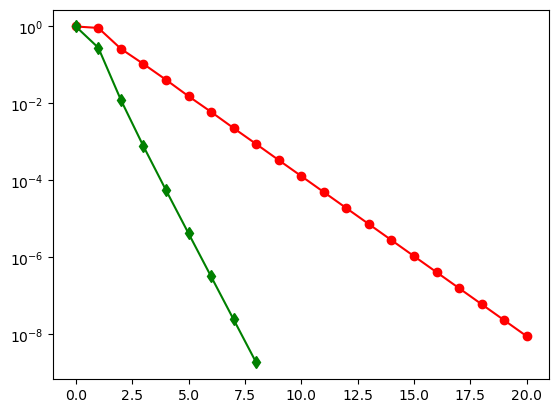

In [7]:
plt.semilogy(np.arange(itJ), err_vet_J, 'ro-', np.arange(itG), err_vet_G, 'gd-')

## Esercizio 2
Testare i metodi di Jacobi e di Gauss Seidel nella soluzione dei sistemi lineare Ax=b, dove 
A=np.array([[0.96326,0.81321],[0.81321,0.68685]])  b=np.array([[0.88824],[0.74988]]) ed iterato iniziale x0=np.array([[0.33116],[0.70000]]). Visualizzare in un grafico in scala semilogaritmica y   l'errore per ogni iterazione per ciascun metodo. Cosa si osserva? Porre toll=1e-8 it_max=30000

In [10]:
A2=np.array([[0.96326,0.81321],[0.81321,0.68685]])
print("Indice di condizionamento ")
b2=np.array([[0.88824],[0.74988]])
x02=np.array([[0.33116],[0.70000]])
it_max2=30000
solJ2, itJ2, err_vet_J2 = jacobi(A2, b2, x02, toll, it_max2)
solG2, itG2, err_vet_G2 = gauss_seidel(A2, b2, x02, toll, it_max2)
print("Soluzione J \n", solJ2)
print("iterazioni J \n", itJ2)
print("Soluzione G \n", solG2)
print("iterazioni G ", itG2)


Indice di condizionamento 
Raggiospettrale di jacobi 0.9997697589137727
Raggiospettrale di Gauss-Seidel 0.9995395708385031
Soluzione J 
 [[0.91112242]
 [0.01302487]]
iterazioni J 
 30001
Soluzione G 
 [[0.91169004]
 [0.01235284]]
iterazioni G  23288


Raggiospettrale di jacobi 0.9997697589137727
1.9579862877125542
Raggiospettrale di Gauss-Seidel-Sor 0.9579862877125548
Soluzione G 
 [[0.91169629]
 [0.01234543]]
iterazioni G  12637


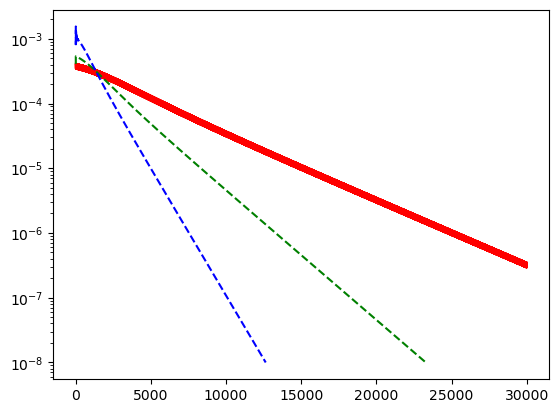

In [14]:
omega_ottimo = 2/(1+np.sqrt(1-raggio_spettrale_jacobi(A2)**2))
print(omega_ottimo)
solG2_sor, itG2_sor, err_vet_G2_sor = gauss_seidel_sor(A2, b2, x02, toll, it_max2, omega_ottimo)
print("Soluzione G \n", solG2_sor)
print("iterazioni G ", itG2_sor)

plt.semilogy(np.arange(itJ2), err_vet_J2, 'r-', np.arange(itG2), err_vet_G2, 'g--', np.arange(itG2_sor), err_vet_G2_sor, 'b--')

## Esercizio 3
Scrivere una funzione creaPoisson(n) che preso in input l'ordine della matrice quadrata di Poisson la costruzione secondo la seguente formula:
$$A =
\left [
\begin{array}{ccccccccccc}
4 & -1 & 0 & -1 &0 &0 & 0& 0& \cdots &   0 & 0\\
-1 & 4 & -1 & 0  &-1 &0 & 0& 0& \cdots &   0 & 0\\
0 & -1 & 4 & -1  &0 &-1 & 0& 0& \cdots &   0 & 0 \\
-1 & 0 & -1 & 4  &-1 &0  & -1 & 0& \cdots &   0 & 0\\
0 & -1 & 0 & -1  & 4 &-1 & 0 & -1& \cdots &   0 & 0\\
0 & 0 & -1 & 0  & -1 &4 & -1 & 0&  -1 & 0 & 0 \\
0 & 0 & 0 & \ddots  & 0 &\ddots & \ddots & \ddots& \ddots & \ddots & 0\\
0 & 0 & 0 & 0  & -1 &0  & -1 & 4& -1 &   0& -1\\
\end{array}
 \right ], \qquad
$$
- Risolvere il sistema lineare Ax=b con matrice dei coefficienti A di Poisson di ordine 10 e termine noto b scelto in maniera tale che il sistema abbia soluzione il vettore x con tutte le componenti  uguali ad 1, utilizzando  il metodo iterativo di Jacobi, Gauss-Seidel e Gauss-Seidel-Sor con parametro omega scelto tra 1 e 2 in maniera tale che il raggio spettrale della matrice di iterazione sia il più piccolo possibile e confrontare su un unico grafico l'andamento degli errori in scala logaritmica. Usare toll=1e-10.

In [16]:
def poisson(n):
    d = np.ones((n)) * 4
    e = -np.ones((n - 1))
    f = -np.ones((n - 3))

## Esercizio 4
Con lo stesso sistema lineare dell'esercizio 2, testa il metodo di Gauss_Seidel SOR , utilizzando selezionando come parametro ottimo $\omega= \frac{2}{1+\sqrt{(1-\rho(T_j)^2}}$